# Project II

##### University of California - Berkeley

##### Chem277a: Data Science for the Molecular Sciences

##### Girish Krishna, Seungho Yoo, Shivani Tijare, Zander Rothering

##### Github Link: https://github.com/Zander-Rothering/Chem277a_Project_II.git

### 1) Objective

Classification of individuals as at risk for Alzheimer's disease using predictive models is critically important given its progressive, irreversible nature and status as the leading cause of dementia worldwide, representing a major and growing public health challenge (Ballard et al., 2011; Lane et al., 2018). Early detection of the disease is especially important, as Alzheimer's has a preclinical phase during which underlying pathological changes occur before clinical symptoms emerge, creating a window for intervention, improved care planning, and the potential slowing of cognitive decline through treatment (Jack et al., 2018; Lane et al., 2018). At the same time, challenges in diagnosis highlight the importance of methods that can integrate a diverse range of features such as age, cognitive scores, medical history, and other risk factors (Ballard et al., 2011). Predictive classification models are well suited to this task, as they capture relationships within data that may not be identified using conventional means. As the prevalence of Alzheimer’s continues to rise and emphasis on risk reduction becomes increasingly important, classification pipelines emerge as an effective means of enhancing diagnostic accuracy, supporting clinical decision-making, and advancing personalized medicine, contributing to improved disease management and healthcare outcomes (Ballard et al., 2011; Lane et al., 2018).

The objective of this project is to provide an overview of a classification pipeline for an Alzheimer's disease dataset using multiple models for classification. The project demonstrates how Alzheimer's data can be analyzed, preprocessed, and ultimately used by a predictive model to classify individuals as having Alzheimer's disease or not. The pipeline begins with exploratory data analysis of the dataset, providing context regarding related features, patterns in the data, and the distribution of data within the feature space. This data analysis is followed by encoding of data features into suitable values for classification models, feature selection for improved model performance, and splitting of the data into training and validation sets. Finally, the project implements and compares the classification of individuals using three models (X, Y, Z) to evaluate their ability to predict Alzheimer's disease outcomes based on input features. This systematic approach to predictive modeling, provides a concise approach to capturing the underlying relationships in data that can be used to predict Alzheimer's disease.

<br>

### 2) Dependencies

Prior to running the pipeline, the following libraries should be imported for data analysis, visualization, encoding, and predicitive modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import *
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

I0000 00:00:1776454832.800103   29642 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<br>

### 3) EDA

In [22]:
alz_data = pd.read_csv('alzheimers_prediction_dataset.csv')
alz_data.head()

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


In [23]:
alz_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Family History 

In [24]:
alz_target = alz_data["Alzheimer’s Diagnosis"]
alz_data_x = alz_data.drop(["Alzheimer’s Diagnosis"], axis = 1)
alz_data_copy = alz_data_x.copy()

numeric_data = ['Age', 'BMI', 'Cognitive Test Score', 'Education Level']
alz_numeric = alz_data_copy[numeric_data]
alz_numeric.head()

,Age,BMI,Cognitive Test Score,Education Level
0,90,33.0,90,1
1,72,29.9,65,7
2,86,22.9,43,19
3,53,31.2,81,17
4,58,30.0,49,3


In [25]:
scaler = MinMaxScaler()
alz_numericS = scaler.fit_transform(alz_numeric)
alz_numericS_df = pd.DataFrame(alz_numericS, columns = numeric_data)

<Axes: >

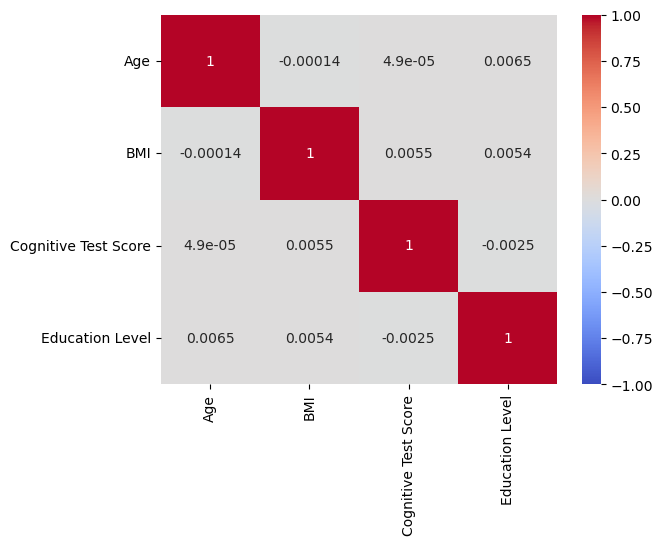

In [33]:
sns.heatmap(alz_numericS_df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

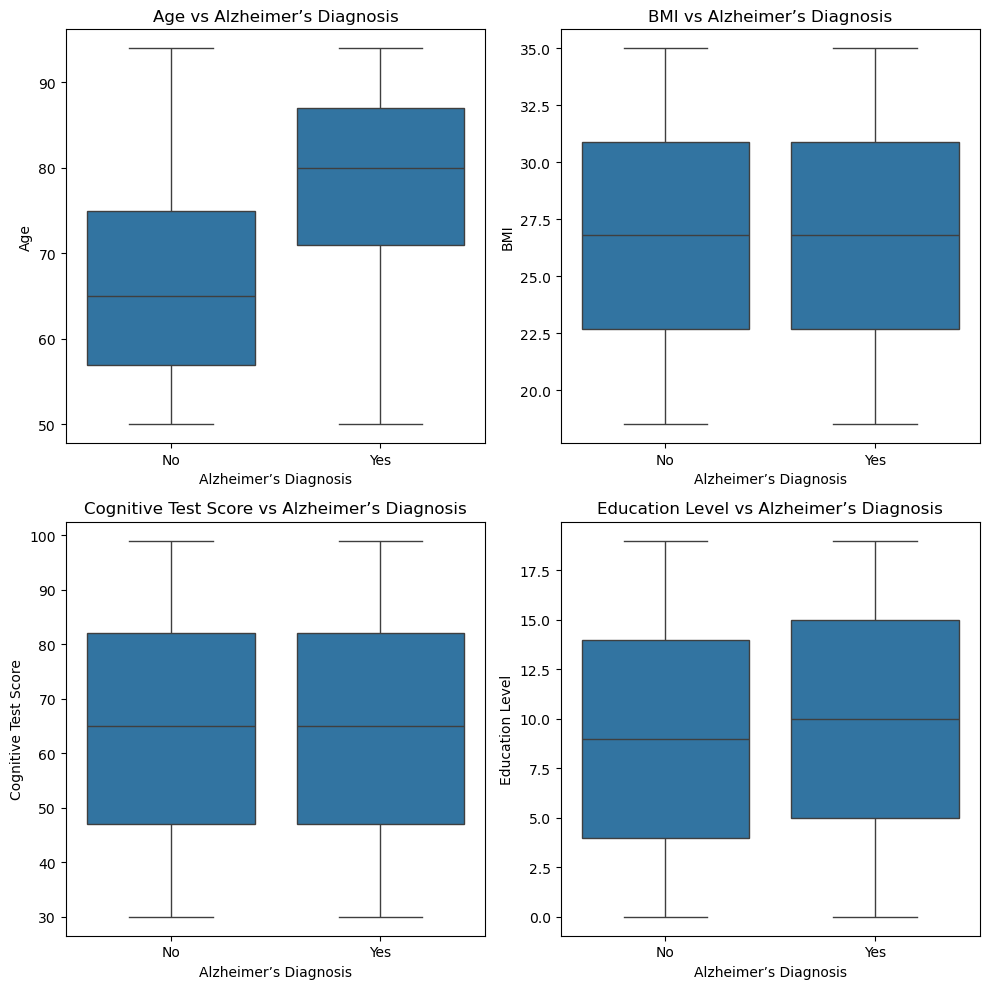

In [29]:
alz_columns_num = alz_numericS_df.columns.tolist()

cols = len(alz_columns)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i, column in enumerate(alz_columns_num):
    sns.boxplot(data=alz_data, x="Alzheimer’s Diagnosis", y=column, ax=axes[i])
    axes[i].set_title(f"{column} vs Alzheimer’s Diagnosis")
plt.tight_layout()
plt.show()

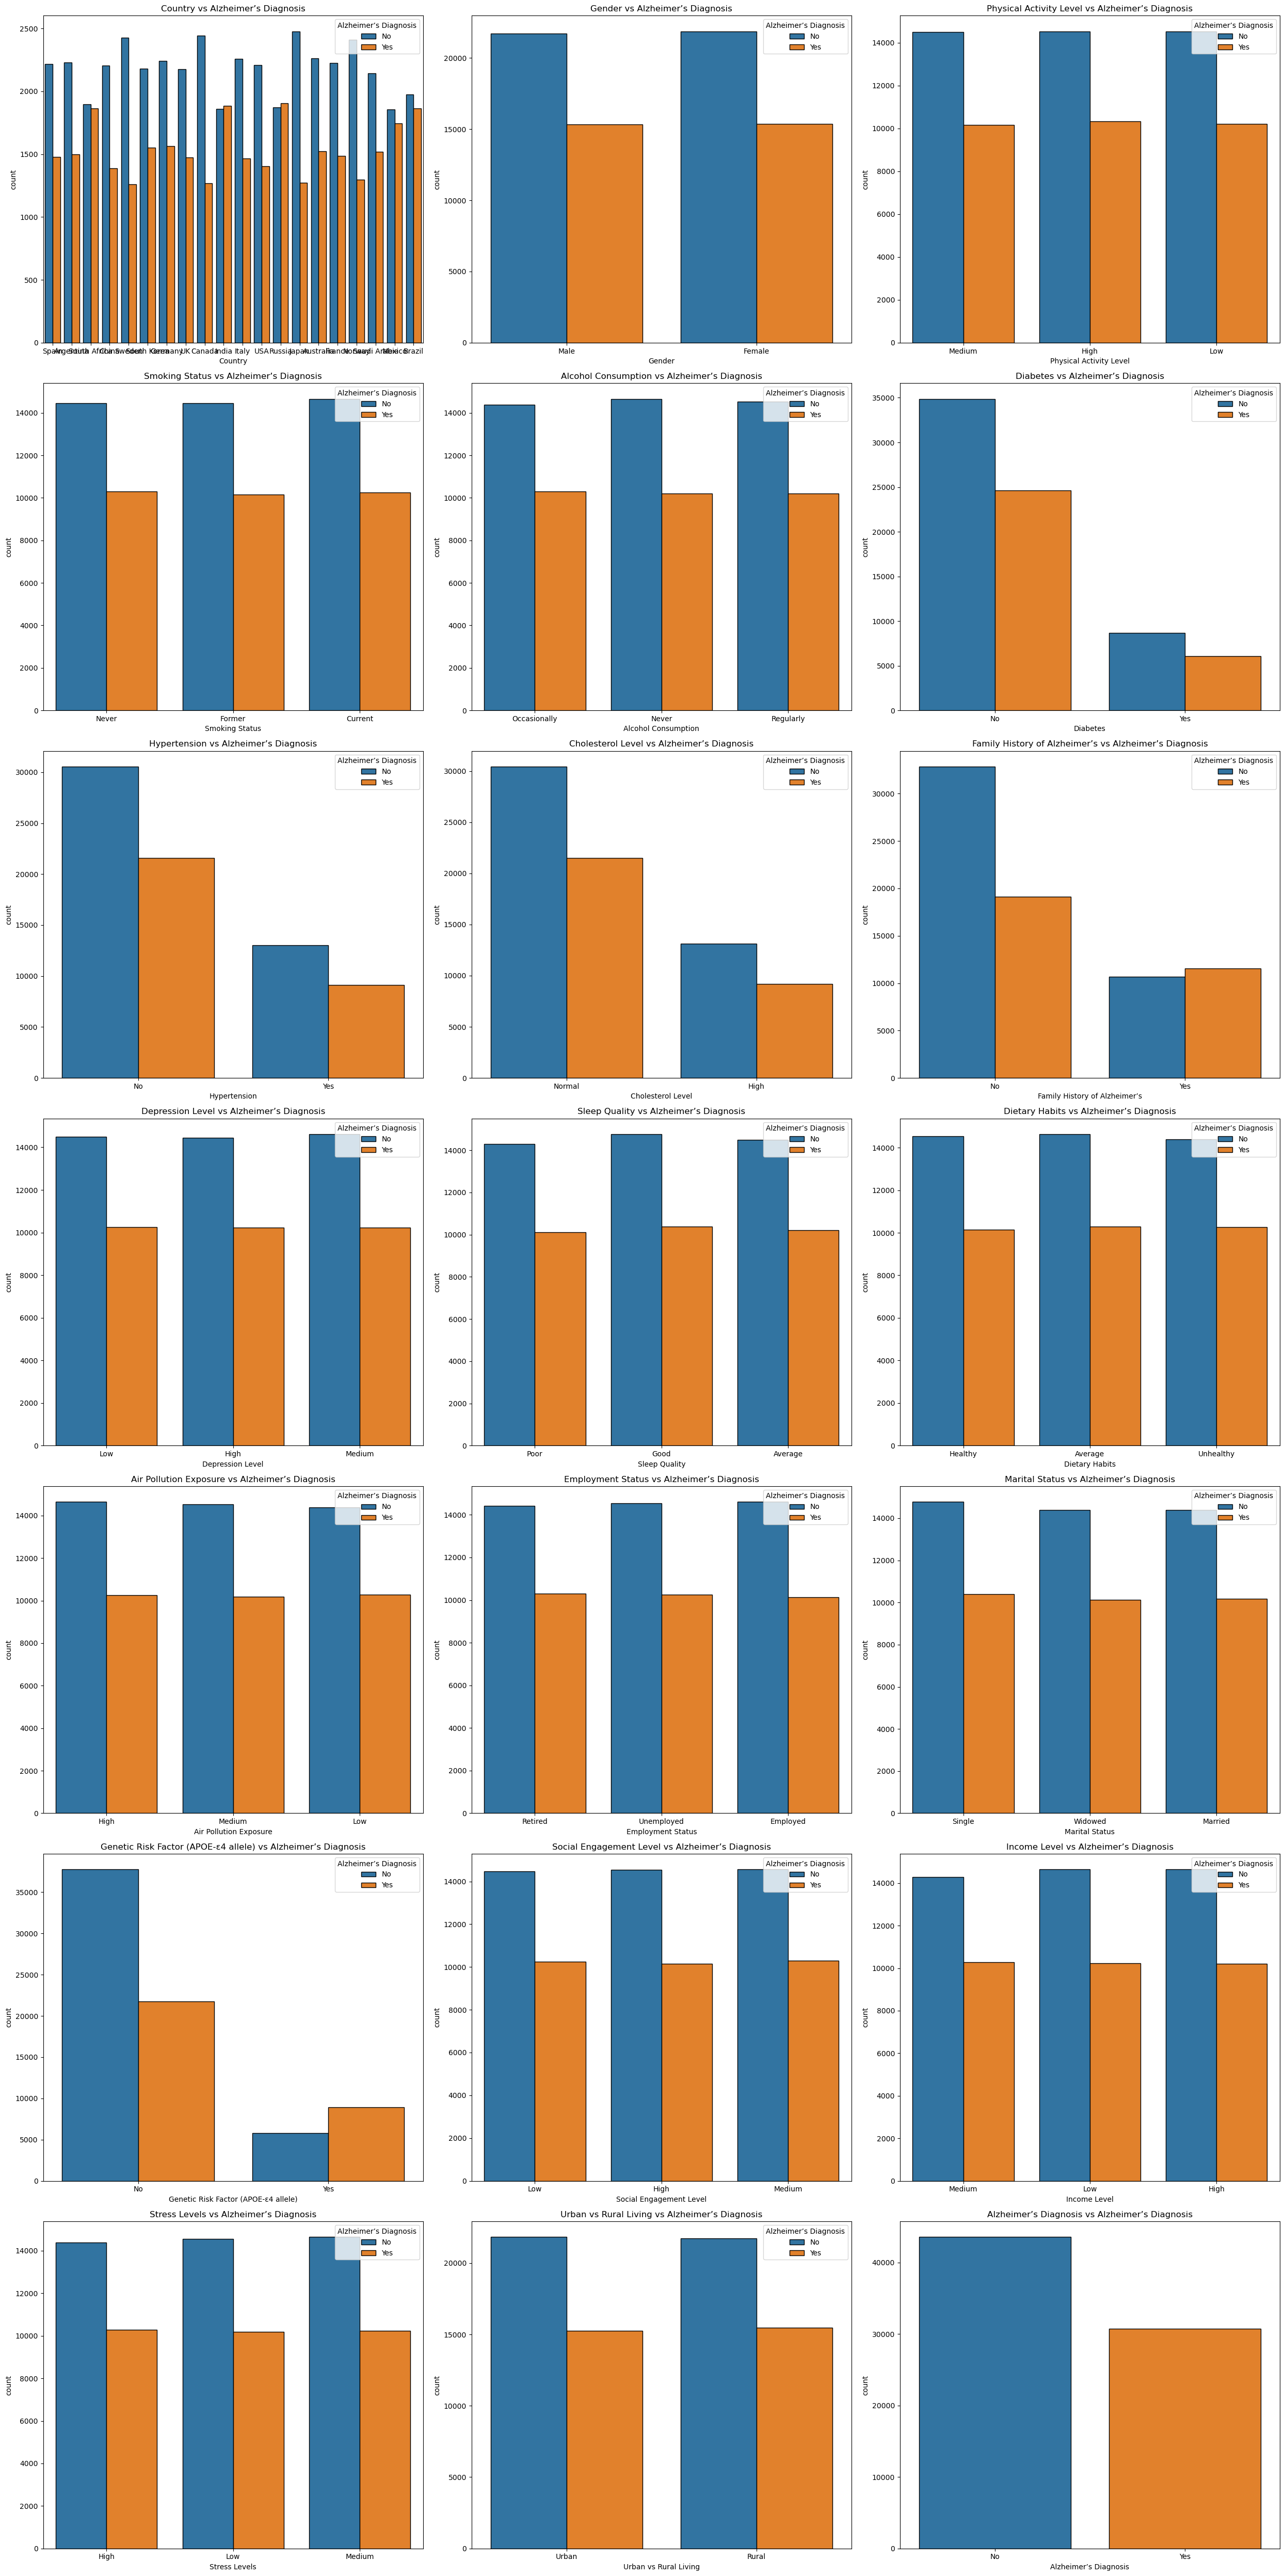

In [32]:
alz_data_cat = alz_data.drop(columns=numeric_data)
alz_columns_cat = alz_data_cat.columns.tolist()

fig, axes = plt.subplots(7, 3, figsize=(25, 50))
axes = axes.flatten()

for i, column in enumerate(alz_columns_cat):
    sns.countplot(data=alz_data, x=column, hue="Alzheimer’s Diagnosis", ax=axes[i], edgecolor='black')
    axes[i].set_title(f"{column} vs Alzheimer’s Diagnosis")

plt.tight_layout()
plt.show()

<br>

### 4) Models

<br>

### 5) Improvements

<br>

### 6) Discussion

<br>

### References

###### 1. Ankit. (2025). Alzheimer’s Prediction Dataset (Global) [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/10618775
###### 2. Ballard, C., Gauthier, S., Corbett, A., Brayne, C., Aarsland, D., & Jones, E. (2011). Alzheimer’s disease. The Lancet, 377(9770), 1019–1031. https://doi.org/10.1016/S0140-6736(10)61349-9
###### 3. Lane, C. A., Hardy, J., & Schott, J. M. (2018). Alzheimer’s disease. European Journal of Neurology, 25(1), 59–70. https://doi.org/10.1111/ene.13439
###### 4. Jack, C. R., Bennett, D. A., Blennow, K., Carrillo, M. C., Dunn, B., Haeberlein, S. B., Holtzman, D. M., Jagust, W., Jessen, F., Karlawish, J., Liu, E., Molinuevo, J. L., Montine, T., Phelps, C., Rankin, K. P., Rowe, C. C., Scheltens, P., Siemers, E., Snyder, H. M., & Sperling, R. (2018). NIA-AA research framework: Toward a biological definition of Alzheimer’s disease. Alzheimer’s & Dementia, 14(4), 535–562. https://doi.org/10.1016/j.jalz.2018.02.018
###### 5.